# Isolation Forest screening of lattice struts

This notebook fits a simple unsupervised Isolation Forest. It identifies unusual combinations of CT continuity and centerline-profile measurements; an anomaly is a candidate for review, not automatically a confirmed defect.

In [2]:
# Run this once if sklearn is missing from the notebook kernel.
%pip install -q scikit-learn pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

pd.set_option('display.max_columns', 100)
RANDOM_STATE = 42

In [4]:
# This works when Jupyter starts either in the repository root or this folder.
base = Path.cwd()
data_dir = base / 'strut_feature_dataset' if (base / 'strut_feature_dataset').exists() else base

struts = pd.read_csv(data_dir / 'strut_features_combined.csv')
profiles = pd.read_csv(data_dir / 'spatial_sequence_anomaly' / 'datasets' / 'centerline_profile_summary.csv')

profile_columns = [
    'specimen_id', 'strut_id', 'profile_relative_mean', 'profile_relative_min',
    'profile_relative_std', 'profile_fraction_below_80pct',
    'profile_longest_run_below_80pct', 'profile_max_absolute_step',
]
df = struts.merge(profiles[profile_columns], on=['specimen_id', 'strut_id'], how='left')
print(f'{len(df):,} struts loaded from {df.specimen_id.nunique()} specimens')
df.head()

18,468 struts loaded from 1 specimens


,specimen_id,strut_id,junction0_id,junction1_id,unit_cell_id,unit_cell_i,unit_cell_j,unit_cell_k,unit_cell_edge_idx,start_x_vox,start_y_vox,start_z_vox,end_x_vox,end_y_vox,end_z_vox,midpoint_x_vox,midpoint_y_vox,midpoint_z_vox,start_x_mm,start_y_mm,start_z_mm,end_x_mm,end_y_mm,end_z_mm,midpoint_x_mm,midpoint_y_mm,midpoint_z_mm,delta_x_mm,delta_y_mm,delta_z_mm,length_mm,nominal_diameter_mm,expected_diameter_voxels,unit_vector_x,unit_vector_y,unit_vector_z,absolute_unit_x,absolute_unit_y,absolute_unit_z,angle_to_build_z_deg,elevation_from_xy_deg,azimuth_xy_deg,orientation_class,junction0_degree,junction1_degree,minimum_endpoint_degree,maximum_endpoint_degree,mean_endpoint_degree,neighboring_strut_count,endpoint_on_boundary_count,minimum_midpoint_boundary_distance_mm,near_boundary_one_cell,cross_section_area_mm2,second_moment_area_mm4,nominal_strut_volume_mm3,nominal_lateral_surface_mm2,slenderness_length_over_diameter,slenderness_length_over_radius_gyration,axial_geometry_proxy_area_over_length_mm,bending_geometry_proxy_i_over_length_cubed_mm,euler_buckling_proxy_pi2_i_over_length2_mm2,ct_features_available,ct_support_fraction,ct_longest_gap_fraction,ct_mean_local_max,ct_min_local_max,ct_profile_min_to_mean,ct_continuity_score,ct_local_baseline_intensity,ct_relative_local_intensity,ct_defect_score,ct_rank_weakest_first,ct_rank_percentile,ct_screening_label,ct_severity_layer,profile_relative_mean,profile_relative_min,profile_relative_std,profile_fraction_below_80pct,profile_longest_run_below_80pct,profile_max_absolute_step
0,0.5-1,0,0,9,0,0,0,0,1,59.339604,52.182893,26.461732,99.028775,91.470245,26.385210,79.184190,71.826569,26.423471,3.447038,3.031304,1.537162,5.752582,5.313507,1.532717,4.599810,4.172405,1.534939,2.305544,2.282202,-0.004445,3.244071,0.35,6.025133,0.710695,0.703499,-0.001370,0.710695,0.703499,0.001370,89.921491,0.078509,44.708491,near_horizontal,3,8,3,8,5.5,9,1,0.112006,1,0.096211,0.000737,0.312116,3.567043,9.268776,37.075103,0.029658,0.000022,0.000691,1,1.000000,0.000000,47514.612903,42271.0,0.889642,1.000000,51399.977832,0.924409,0.083240,1979,0.107158,supported,supported,0.924409,0.822393,0.044758,0.00000,0,0.020292
1,0.5-1,1,1,9,0,0,0,0,2,138.316175,51.781302,26.527177,99.028775,91.470245,26.385210,118.672475,71.625774,26.456193,8.034787,3.007976,1.540964,5.752582,5.313507,1.532717,6.893684,4.160741,1.536840,-2.282205,2.305531,-0.008247,3.244071,0.35,6.025133,-0.703500,0.710690,-0.002542,0.703500,0.710690,0.002542,89.854346,0.145654,134.708691,near_horizontal,2,8,2,8,5.0,8,0,0.113906,1,0.096211,0.000737,0.312116,3.567043,9.268776,37.075103,0.029658,0.000022,0.000691,1,1.000000,0.000000,51135.806452,50506.0,0.987684,1.000000,53243.280748,0.960418,0.033584,6800,0.368204,supported,supported,0.960418,0.948589,0.015543,0.00000,0,0.030727
2,0.5-1,2,2,9,0,0,0,0,3,138.717946,130.757597,26.308688,99.028775,91.470245,26.385210,118.873360,111.113921,26.346949,8.058125,7.595709,1.528272,5.752582,5.313507,1.532717,6.905354,6.454608,1.530494,-2.305544,-2.282202,0.004445,3.244071,0.35,6.025133,-0.710695,-0.703499,0.001370,0.710695,0.703499,0.001370,89.921491,0.078509,224.708491,near_horizontal,1,8,1,8,4.5,7,0,0.107560,1,0.096211,0.000737,0.312116,3.567043,9.268776,37.075103,0.029658,0.000022,0.000691,1,1.000000,0.000000,50537.032258,49871.0,0.986821,1.000000,52835.621592,0.956495,0.036833,6461,0.349848,supported,supported,0.956495,0.943890,0.007664,0.00000,0,0.017659
3,0.5-1,3,3,9,0,0,0,0,0,59.741375,131.159188,26.243243,99.028775,91.470245,26.385210,79.385075,111.314717,26.314226,3.470376,7.619037,1.524470,5.752582,5.313507,1.532717,4.611479,6.466272,1.528593,2.282205,-2.305531,0.008247,3.244071,0.35,6.025133,0.703500,-0.710690,0.002542,0.703500,0.710690,0.002542,89.854346,0.145654,314.708691,near_horizontal,2,8,2,8,5.0,8,1,0.105660,1,0.096211,0.000737,0.312116,3.567043,9.268776,37.075103,0.029658,0.000022,0.000691,1,1.000000,0.000000,49925.258065,48945.0,0.980365,1.000000,51006.431993,0.978803,0.020853,8230,0.445636,suppo

In [5]:
# Features describe missing support, intensity weakness, profile shape, and geometry.
# ct_defect_score and existing labels are deliberately excluded from model fitting.
numeric_features = [
    'ct_support_fraction', 'ct_longest_gap_fraction',
    'ct_relative_local_intensity', 'ct_profile_min_to_mean',
    'ct_continuity_score', 'profile_relative_mean',
    'profile_relative_min', 'profile_relative_std',
    'profile_fraction_below_80pct', 'profile_longest_run_below_80pct',
    'profile_max_absolute_step', 'length_mm', 'angle_to_build_z_deg',
]
categorical_features = ['orientation_class']

preprocess = ColumnTransformer([
    ('numeric', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', RobustScaler()),
    ]), numeric_features),
    ('category', OneHotEncoder(handle_unknown='ignore'), categorical_features),
])

# 1% is a screening budget, not an estimate of the true defect rate.
model = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    max_samples='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
pipeline = Pipeline([('preprocess', preprocess), ('model', model)])

In [6]:
X = df[numeric_features + categorical_features]
pipeline.fit(X)

# sklearn returns -1 for anomalies. Higher anomaly_score below means more unusual.
df['isolation_forest_label'] = pipeline.predict(X)
df['isolation_forest_anomaly'] = df['isolation_forest_label'] == -1
df['isolation_forest_anomaly_score'] = -pipeline.decision_function(X)

n_anomalies = int(df['isolation_forest_anomaly'].sum())
print(f'Flagged {n_anomalies:,} / {len(df):,} struts ({n_anomalies / len(df):.2%})')

Flagged 185 / 18,468 struts (1.00%)


In [7]:
review_columns = [
    'specimen_id', 'strut_id', 'isolation_forest_anomaly_score',
    'ct_support_fraction', 'ct_relative_local_intensity',
    'profile_relative_mean', 'profile_fraction_below_80pct',
    'profile_longest_run_below_80pct', 'ct_defect_score', 'ct_severity_layer',
]
top_candidates = (
    df.loc[df['isolation_forest_anomaly'], review_columns]
      .sort_values('isolation_forest_anomaly_score', ascending=False)
)
top_candidates.head(20)

,specimen_id,strut_id,isolation_forest_anomaly_score,ct_support_fraction,ct_relative_local_intensity,profile_relative_mean,profile_fraction_below_80pct,profile_longest_run_below_80pct,ct_defect_score,ct_severity_layer
13663,0.5-1,13663,0.054647,0.000000,0.630435,0.630435,1.000000,31,0.294493,critical
13884,0.5-1,13884,0.052079,0.032258,0.650750,0.650750,0.967742,30,0.279066,critical
13638,0.5-1,13638,0.050724,0.032258,0.662934,0.662934,0.967742,30,0.270682,high
14625,0.5-1,14625,0.049906,0.000000,0.615027,0.615027,1.000000,31,0.308340,critical
11766,0.5-1,11766,0.048283,0.000000,0.741553,0.741553,1.000000,31,0.206639,high
14210,0.5-1,14210,0.048153,0.032258,0.653639,0.653639,0.935484,29,0.280604,critical
8114,0.5-1,8114,0.046874,0.064516,0.626367,0.626367,0.935484,29,0.302679,critical
13857,0.5-1,13857,0.043630,0.064516,0.654480,0.654480,0.935484,29,0.281778,critical
14576,0.5-1,14576,0.042682,0.096774,0.639736,0.639736,0.903226,28,0.295694,critical
8136,0.5-1,8136,0.040450,0.129032,0.645564,0.645564,0.870968,27,0.296226,critical


In [8]:
# Existing high/critical ranks are a useful consistency check, not independent truth.
existing_candidate = df['ct_severity_layer'].isin(['high', 'critical'])
comparison = pd.crosstab(
    existing_candidate.map({False: 'not high/critical', True: 'high/critical'}),
    df['isolation_forest_anomaly'].map({False: 'IF normal', True: 'IF anomaly'}),
)
display(comparison)

overlap = int((existing_candidate & df['isolation_forest_anomaly']).sum())
print(f'Overlap: {overlap} of {existing_candidate.sum()} existing high/critical candidates')

isolation_forest_anomaly,IF anomaly,IF normal
ct_severity_layer,,
high/critical,85,7
not high/critical,100,18276


Overlap: 85 of 92 existing high/critical candidates


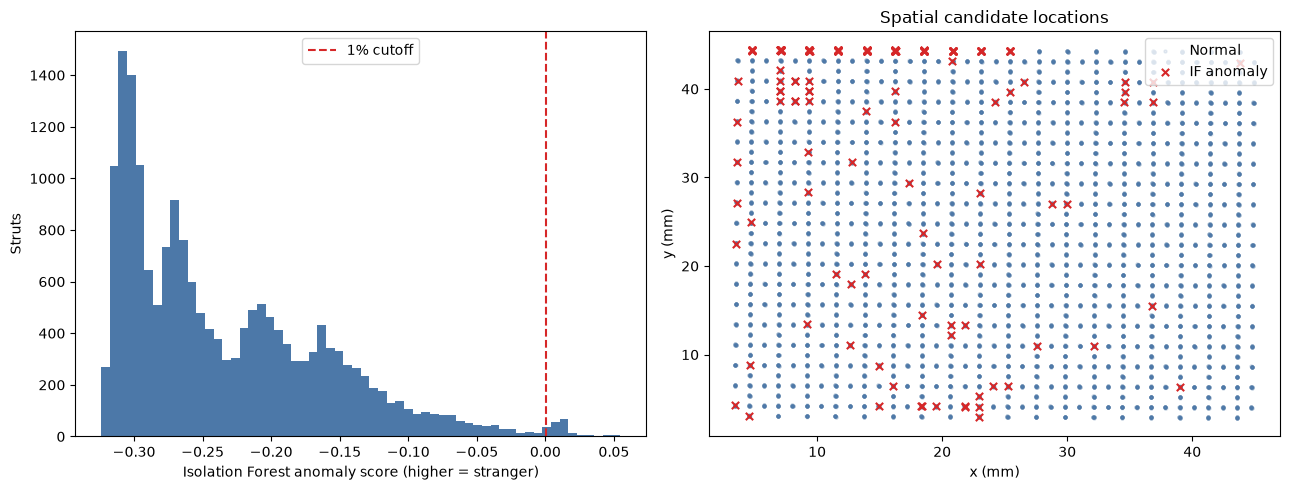

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['isolation_forest_anomaly_score'], bins=60, color='#4c78a8')
threshold = df.loc[df['isolation_forest_anomaly'], 'isolation_forest_anomaly_score'].min()
axes[0].axvline(threshold, color='#d62728', linestyle='--', label='1% cutoff')
axes[0].set(xlabel='Isolation Forest anomaly score (higher = stranger)', ylabel='Struts')
axes[0].legend()

normal = ~df['isolation_forest_anomaly']
axes[1].scatter(
    df.loc[normal, 'midpoint_x_mm'], df.loc[normal, 'midpoint_y_mm'],
    s=5, alpha=0.12, color='#4c78a8', label='Normal',
)
axes[1].scatter(
    df.loc[~normal, 'midpoint_x_mm'], df.loc[~normal, 'midpoint_y_mm'],
    s=28, marker='x', color='#d62728', label='IF anomaly',
)
axes[1].set(xlabel='x (mm)', ylabel='y (mm)', title='Spatial candidate locations')
axes[1].legend()

fig.tight_layout()
plt.show()

In [10]:
output_path = data_dir / 'spatial_sequence_anomaly' / 'datasets' / 'isolation_forest_results.csv'
df[['specimen_id', 'strut_id', 'isolation_forest_anomaly',
    'isolation_forest_anomaly_score', 'ct_severity_layer']].to_csv(output_path, index=False)
print(f'Saved results to: {output_path.resolve()}')

Saved results to: C:\Users\oconn\DSC2026\llnl_data_science_challenge_2026\strut_feature_dataset\spatial_sequence_anomaly\datasets\isolation_forest_results.csv
